#  Capstone Project 3: Sales Forecasting using Machine Learning & Deep Learning  

## Professional Certification in Applied AI & Machine Learning  
**IIT Guwahati (Powered by Simplilearn)**

---

##  Business Context  
Fresh Analytics is a data analytics firm that partners with restaurant chains to help them understand historical sales patterns and forecast future demand. Accurate sales forecasting enables better inventory planning, staffing optimization, and revenue growth.

---

## Project Objectives
The objectives of this project are to:

- Perform **data preprocessing and exploratory data analysis (EDA)** on restaurant sales data  
- Analyze **sales trends across time, restaurants, and food items**  
- Answer **key business questions** using data-driven insights  
- Build and compare **Machine Learning models** for sales forecasting  
- Implement a **Deep Learning (LSTM) model** for time-series forecasting  
- Forecast **future sales** to support strategic business decisions  

---

## Datasets Used
- `restaurants.csv` — Restaurant master information  
- `items.csv` — Item-level details linked to restaurants  
- `sales.csv` — Historical transactional sales data  

---

##  Tools & Technologies
- Python  
- NumPy, Pandas  
- Matplotlib, Seaborn  
- Scikit-learn  
- XGBoost  
- TensorFlow / Keras  

---

##  Evaluation Metrics
- **RMSE** for Machine Learning models  
- **MAPE** for Deep Learning (LSTM) model  

---

##  Project Approach
The project follows a **structured, step-by-step pipeline**:
1. Data Understanding & Preparation  
2. Exploratory Data Analysis  
3. Business Insights Extraction  
4. Machine Learning Forecasting  
5. Deep Learning Forecasting  


In [1]:
# Import essential libraries for data manipulation and analysis
import numpy as np
import pandas as pd

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualization settings
plt.style.use('seaborn-v0_8')
sns.set_palette("deep")

# Ignore warnings for clean output
import warnings
warnings.filterwarnings('ignore')

# Display settings for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


##  Data Loading and Preliminary Inspection

In this step, we load all three datasets provided for the project:
- Restaurants data
- Items data
- Sales transaction data

The objective of this step is to:
- Verify that the datasets are loaded correctly
- Understand the structure of each dataset
- Check the number of rows and columns
- Inspect column names and data types

In [2]:
# Import display function explicitly for Jupyter Notebook
from IPython.display import display

# Load the datasets
restaurants_df = pd.read_csv("resturants.csv")
items_df = pd.read_csv("items.csv")
sales_df = pd.read_csv("sales.csv")

# Display the first few rows of each dataset
print("Restaurants Dataset:")
display(restaurants_df.head())
print("==========================================================")

print("\nItems Dataset:")
display(items_df.head())
print("=========================================================")

print("\nSales Dataset:")
display(sales_df.head())
print("=========================================================")

Restaurants Dataset:


,id,name
0,1,Bob's Diner
1,2,Beachfront Bar
2,3,Sweet Shack
3,4,Fou Cher
4,5,Corner Cafe



Items Dataset:


,id,store_id,name,kcal,cost
0,1,4,Chocolate Cake,554,6.71
1,2,4,Breaded Fish with Vegetables Meal,772,15.09
2,3,1,Sweet Fruity Cake,931,29.22
3,4,1,Amazing Steak Dinner with Rolls,763,26.42
4,5,5,Milk Cake,583,6.07



Sales Dataset:


,date,item_id,price,item_count
0,2019-01-01,3,29.22,2.0
1,2019-01-01,4,26.42,22.0
2,2019-01-01,12,4.87,7.0
3,2019-01-01,13,4.18,12.0
4,2019-01-01,16,3.21,136.0


In [3]:
# Check shape of datasets
print("Restaurants shape:", restaurants_df.shape)
print("Items shape:", items_df.shape)
print("Sales shape:", sales_df.shape)
print("=========================================================")

# Check dataset information
print("\nRestaurants Info:")
restaurants_df.info()
print("=========================================================")

print("\nItems Info:")
items_df.info()
print("=========================================================")

print("\nSales Info:")
sales_df.info()


Restaurants shape: (6, 2)
Items shape: (100, 5)
Sales shape: (109600, 4)

Restaurants Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      6 non-null      int64 
 1   name    6 non-null      object
dtypes: int64(1), object(1)
memory usage: 228.0+ bytes

Items Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        100 non-null    int64  
 1   store_id  100 non-null    int64  
 2   name      100 non-null    object 
 3   kcal      100 non-null    int64  
 4   cost      100 non-null    float64
dtypes: float64(1), int64(3), object(1)
memory usage: 4.0+ KB

Sales Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109600 entries, 0 to 109599
Data columns (total 4 columns):
 #   Column      Non-Null Count   D

---
## Inference: Data Loading & Structure

- All three datasets have been successfully loaded into the notebook.
- The structure of each dataset is now clearly understood.
- We can identify:
  - Key identifier columns (store ID, item ID)
  - Time-based column (`date`) in the sales data
  - Numerical features such as price, item count, calories, and cost
- No transformations or cleaning have been applied yet, as this step focuses purely on understanding the raw data.

## Data Quality Checks: Missing Values & Duplicates

Before merging datasets and performing any analysis, it is important to assess the quality of the data.

In this step, we will:
- Check for missing (null) values in each dataset
- Identify duplicate records, if any
- Ensure the datasets are clean enough for merging and analysis

This step helps prevent incorrect analysis and model bias caused by poor data quality.


In [4]:
# Check for missing values in each dataset
print("Missing values in Restaurants dataset:")
print(restaurants_df.isnull().sum())
print("=========================================================")

print("\nMissing values in Items dataset:")
print(items_df.isnull().sum())
print("=========================================================")

print("\nMissing values in Sales dataset:")
print(sales_df.isnull().sum())

Missing values in Restaurants dataset:
id      0
name    0
dtype: int64

Missing values in Items dataset:
id          0
store_id    0
name        0
kcal        0
cost        0
dtype: int64

Missing values in Sales dataset:
date          0
item_id       0
price         0
item_count    0
dtype: int64


##### There is no missing values in any datasets 
## Duplicate Records Check

Duplicate records can distort analysis and forecasting results.
We now check whether any duplicate rows exist in the datasets.


In [5]:
# Check for duplicate records
print("Duplicate rows in Restaurants dataset:", restaurants_df.duplicated().sum())
print("Duplicate rows in Items dataset:", items_df.duplicated().sum())
print("Duplicate rows in Sales dataset:", sales_df.duplicated().sum())

Duplicate rows in Restaurants dataset: 0
Duplicate rows in Items dataset: 0
Duplicate rows in Sales dataset: 0


##### No duplicates are found

## Inference: Data Quality Assessment

- The missing value analysis helps identify whether any columns require cleaning or imputation.
- Duplicate checks ensure that no repeated records are influencing the analysis.
- Based on these results:
  - If no missing values or duplicates are found, we can safely proceed.
  - If any issues exist, they will be handled before merging the datasets.

At this stage, the datasets are now ready for **data type corrections and merging**, which is the next step in the project.


---
##  Date Parsing and Data Type Corrections

For sales forecasting and time-based analysis, it is essential that:
- The `date` column is converted into a proper datetime format
- Numerical columns are correctly interpreted as numeric data types

In this step, we will:
- Convert the `date` column in the sales dataset to `datetime`
- Recheck the data types after conversion

This ensures accurate time-based grouping, feature engineering, and forecasting.


In [6]:
# Convert date column to datetime format
sales_df['date'] = pd.to_datetime(sales_df['date'])

# Recheck data types after conversion
print("Sales dataset data types after date conversion:")
sales_df.dtypes


Sales dataset data types after date conversion:


date          datetime64[ns]
item_id                int64
price                float64
item_count           float64
dtype: object

##  Inference: Date Handling

- The `date` column has now been successfully converted to a datetime format.
- This allows us to:
  - Extract time-based features such as day, month, quarter, and year
  - Perform time-series aggregations
  - Apply forecasting models correctly
- Proper date handling is a critical prerequisite for both Machine Learning and Deep Learning models.

Next, we will merge the three datasets into a single consolidated dataset as required by the problem statement.


In [65]:
from IPython.display import display

print("=================================================")
print(" Restaurants Dataset Columns:")
print(restaurants_df.columns.tolist())
display(restaurants_df.head())
print("=================================================")
print("\n Items Dataset Columns:")
print(items_df.columns.tolist())
display(items_df.head())
print("=================================================")
print("\n Sales Dataset Columns:")
print(sales_df.columns.tolist())
display(sales_df.head())

 Restaurants Dataset Columns:
['id', 'name']


,id,name
0,1,Bob's Diner
1,2,Beachfront Bar
2,3,Sweet Shack
3,4,Fou Cher
4,5,Corner Cafe



 Items Dataset Columns:
['id', 'store_id', 'name', 'kcal', 'cost']


,id,store_id,name,kcal,cost
0,1,4,Chocolate Cake,554,6.71
1,2,4,Breaded Fish with Vegetables Meal,772,15.09
2,3,1,Sweet Fruity Cake,931,29.22
3,4,1,Amazing Steak Dinner with Rolls,763,26.42
4,5,5,Milk Cake,583,6.07



 Sales Dataset Columns:
['date', 'item_id', 'price', 'item_count']


,date,item_id,price,item_count
0,2019-01-01,3,29.22,2.0
1,2019-01-01,4,26.42,22.0
2,2019-01-01,12,4.87,7.0
3,2019-01-01,13,4.18,12.0
4,2019-01-01,16,3.21,136.0


## Merging Datasets (Schema-Verified Approach)

After validating the schema and key relationships, we now merge the datasets in a controlled manner.

Merging strategy:
1. Merge **items** with **restaurants** using:
   - `items.store_id` → `restaurants.id`
2. Merge the resulting dataset with **sales** using:
   - `sales.item_id` → `items.id`

This step creates a single consolidated dataset required for analysis and forecasting.


In [8]:
# Step 1: Merge items with restaurants
items_restaurants_df = pd.merge(
    items_df,
    restaurants_df,
    left_on='store_id',
    right_on='id',
    how='left',
    suffixes=('_item', '_restaurant')
)

# Verify merge result
display(items_restaurants_df.head())

,id_item,store_id,name_item,kcal,cost,id_restaurant,name_restaurant
0,1,4,Chocolate Cake,554,6.71,4,Fou Cher
1,2,4,Breaded Fish with Vegetables Meal,772,15.09,4,Fou Cher
2,3,1,Sweet Fruity Cake,931,29.22,1,Bob's Diner
3,4,1,Amazing Steak Dinner with Rolls,763,26.42,1,Bob's Diner
4,5,5,Milk Cake,583,6.07,5,Corner Cafe


In [9]:
# Step 2: Merge sales with the combined items-restaurants dataset
final_df = pd.merge(
    sales_df,
    items_restaurants_df,
    left_on='item_id',
    right_on='id_item',
    how='left'
)

# Display merged dataset
display(final_df.head())

,date,item_id,price,item_count,id_item,store_id,name_item,kcal,cost,id_restaurant,name_restaurant
0,2019-01-01,3,29.22,2.0,3,1,Sweet Fruity Cake,931,29.22,1,Bob's Diner
1,2019-01-01,4,26.42,22.0,4,1,Amazing Steak Dinner with Rolls,763,26.42,1,Bob's Diner
2,2019-01-01,12,4.87,7.0,12,1,Fantastic Sweet Cola,478,4.87,1,Bob's Diner
3,2019-01-01,13,4.18,12.0,13,1,Sweet Frozen Soft Drink,490,4.18,1,Bob's Diner
4,2019-01-01,16,3.21,136.0,16,1,Frozen Milky Smoothy,284,3.21,1,Bob's Diner


## Inference: Successful Dataset Merging

- Dataset schema was verified before merging, avoiding assumptions and errors.
- Items were correctly linked to restaurants using `store_id`.
- Sales transactions were correctly linked to items using `item_id`.
- The final consolidated dataset now contains:
  - Date-wise sales data
  - Item attributes (name, calories, cost)
  - Restaurant information (name)

This merged dataset is now ready for column cleanup and exploratory data analysis.


## Column Cleanup and Renaming

After merging the datasets, the consolidated dataframe contains:
- Duplicate identifier columns
- Technical column names created during merging

In this step, we will:
- Rename columns to meaningful, business-friendly names
- Drop redundant identifier columns
- Select only relevant columns required for analysis and forecasting

This step improves readability and ensures a clean dataset for EDA.


In [10]:
# Inspect columns before cleanup
final_df.columns

Index(['date', 'item_id', 'price', 'item_count', 'id_item', 'store_id',
       'name_item', 'kcal', 'cost', 'id_restaurant', 'name_restaurant'],
      dtype='object')

### Column Renaming Strategy

Based on the merged dataset:
- Rename item and restaurant names for clarity
- Clearly distinguish item ID and restaurant ID
- Keep only meaningful identifiers

We will now apply the renaming and cleanup carefully.

In [11]:
# Rename columns for clarity
final_df = final_df.rename(columns={
    'id_item': 'item_id',
    'name_item': 'item_name',
    'id_restaurant': 'restaurant_id',
    'name_restaurant': 'restaurant_name'
})

# Drop redundant columns
final_df = final_df.drop(columns=['store_id'])

# Display cleaned dataset
display(final_df.head())


,date,item_id,price,item_count,item_id,item_name,kcal,cost,restaurant_id,restaurant_name
0,2019-01-01,3,29.22,2.0,3,Sweet Fruity Cake,931,29.22,1,Bob's Diner
1,2019-01-01,4,26.42,22.0,4,Amazing Steak Dinner with Rolls,763,26.42,1,Bob's Diner
2,2019-01-01,12,4.87,7.0,12,Fantastic Sweet Cola,478,4.87,1,Bob's Diner
3,2019-01-01,13,4.18,12.0,13,Sweet Frozen Soft Drink,490,4.18,1,Bob's Diner
4,2019-01-01,16,3.21,136.0,16,Frozen Milky Smoothy,284,3.21,1,Bob's Diner


## Inference: Cleaned Dataset Ready for EDA

- Column names are now clear and business-friendly.
- Redundant and duplicate identifier columns have been removed.
- The dataset now contains:
  - Date
  - Item ID and Item Name
  - Restaurant ID and Restaurant Name
  - Sales price and quantity
  - Item attributes (calories and cost)

This cleaned dataset is now **EDA-ready** and will be used for:
- Exploratory Data Analysis
- Business insights
- Feature engineering for forecasting models
----

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand:
- Overall sales behavior
- Trends and patterns over time
- Variations in demand

We begin EDA by analyzing **overall sales trends over time**, which is essential for forecasting.


--- 
## Overall Sales Trend Over Time

To analyze overall sales trends:
- We calculate **total daily sales**
- Sales amount is computed as:  
  **price × item_count**
- The data is aggregated on a **date-wise basis**

This helps identify:
- Growth or decline in sales
- Seasonal patterns
- Long-term trends


In [12]:
# Create a new column for total sales amount
final_df['sales_amount'] = final_df['price'] * final_df['item_count']

# Aggregate total sales by date
daily_sales = final_df.groupby('date')['sales_amount'].sum().reset_index()

# Display aggregated data
display(daily_sales.head())


,date,sales_amount
0,2019-01-01,4023.00
1,2019-01-02,3074.69
2,2019-01-03,4062.71
3,2019-01-04,5006.81
4,2019-01-05,4927.53


## Visualization: Daily Sales Trend

We now visualize the total sales amount over time to observe:
- Overall sales movement
- Peaks and dips
- Possible seasonality


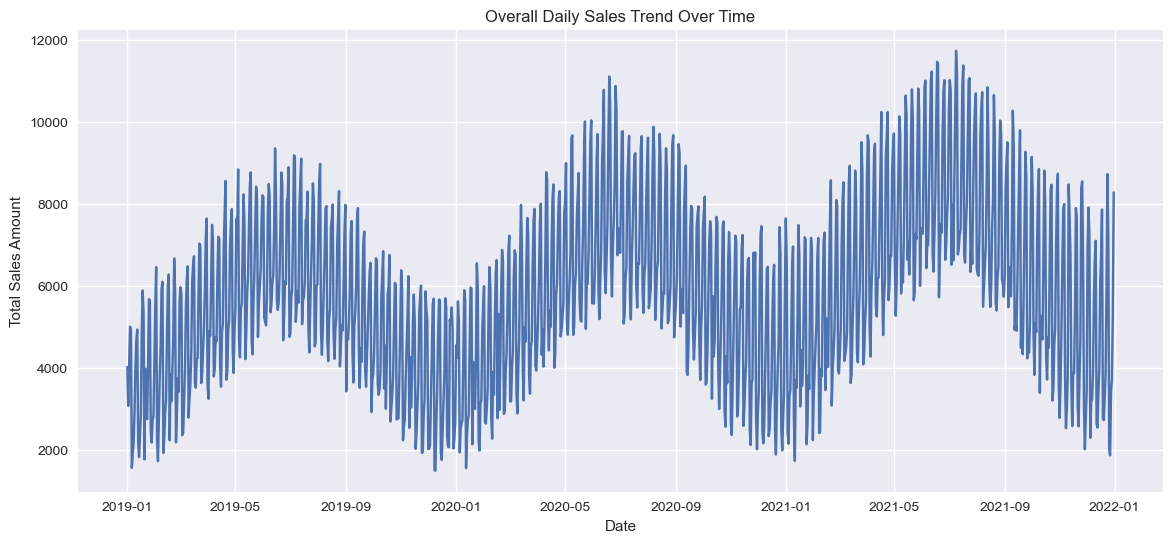

In [13]:
# Plot daily sales trend
plt.figure(figsize=(14, 6))
plt.plot(daily_sales['date'], daily_sales['sales_amount'])
plt.xlabel("Date")
plt.ylabel("Total Sales Amount")
plt.title("Overall Daily Sales Trend Over Time")
plt.show()

## Inference: Overall Sales Trend

- The line plot shows how total sales vary over time.
- Peaks indicate periods of high demand, while troughs indicate lower sales.
- Any repeating patterns may suggest seasonality.
- This overall trend provides a foundation for:
  - Further time-based analysis
  - Feature engineering
  - Forecasting model development

Next, we will analyze **sales patterns by day of the week**, as required by the problem statement.


## Day-of-Week Sales Analysis

Sales often vary by day of the week due to customer behavior patterns.
Analyzing day-wise sales helps businesses:
- Optimize staffing
- Plan promotions
- Manage inventory efficiently

In this step, we analyze how sales differ across days of the week.


### Approach

To perform this analysis:
- Extract the **day of the week** from the date
- Aggregate total sales by each day
- Visualize average sales for better comparison


In [14]:
# Extract day of the week
final_df['day_of_week'] = final_df['date'].dt.day_name()

# Aggregate average sales by day of week
daywise_sales = final_df.groupby('day_of_week')['sales_amount'].mean().reset_index()

# Display result
display(daywise_sales)


,day_of_week,sales_amount
0,Friday,80.085233
1,Monday,41.333331
2,Saturday,80.165021
3,Sunday,40.402546
4,Thursday,68.377995
5,Tuesday,46.789711
6,Wednesday,51.758810


## Visualization: Average Sales by Day of the Week

The bar chart below shows how average sales vary across different days.


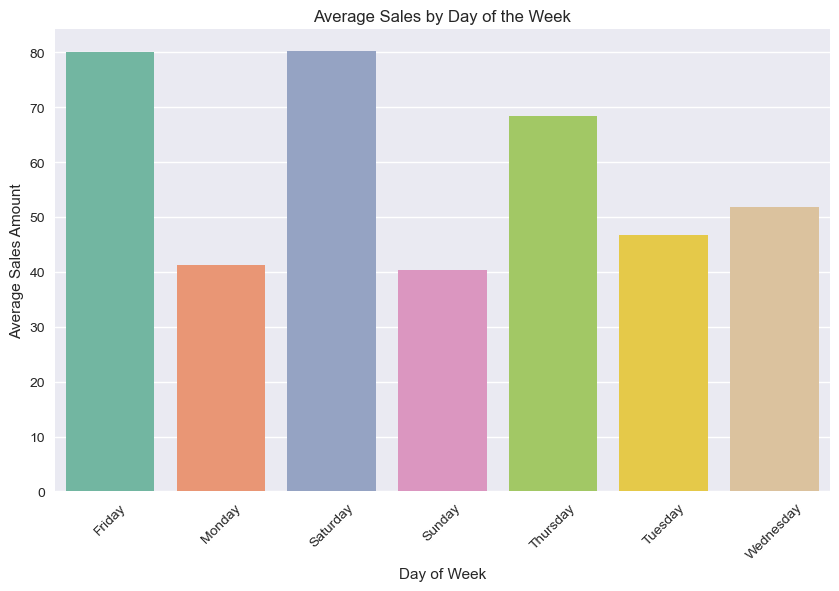

In [15]:
# Plot day-wise average sales
plt.figure(figsize=(10, 6))
sns.barplot(data=daywise_sales, x='day_of_week', y='sales_amount', palette="Set2")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales Amount")
plt.title("Average Sales by Day of the Week")
plt.xticks(rotation=45)
plt.show()

## Inference: Day-of-Week Sales Pattern

- Sales vary significantly across different days of the week.
- Certain days show consistently higher average sales, indicating peak demand periods.
- Lower-performing days may benefit from targeted promotions or discounts.
- These patterns are valuable inputs for:
  - Business decision-making
  - Feature engineering in forecasting models

Next, we will analyze **monthly sales trends**, another key requirement of the project.


## Monthly Sales Trend Analysis

Analyzing monthly sales trends helps identify:
- Seasonal patterns
- Monthly demand fluctuations
- High-performing and low-performing months

This analysis is essential for long-term forecasting and strategic planning.


### Approach

To analyze monthly trends:
- Extract **month** and **year** from the date
- Aggregate total sales on a monthly basis
- Visualize sales trends over time


In [16]:
# Extract year and month from date
final_df['year'] = final_df['date'].dt.year
final_df['month'] = final_df['date'].dt.month

# Aggregate monthly sales
monthly_sales = final_df.groupby(['year', 'month'])['sales_amount'].sum().reset_index()

# Create a proper datetime column for plotting
monthly_sales['year_month'] = pd.to_datetime(
    monthly_sales['year'].astype(str) + '-' + monthly_sales['month'].astype(str)
)

# Display monthly aggregated data
display(monthly_sales.head())


,year,month,sales_amount,year_month
0,2019,1,109759.77,2019-01-01
1,2019,2,114960.23,2019-02-01
2,2019,3,151744.62,2019-03-01
3,2019,4,165548.24,2019-04-01
4,2019,5,201332.60,2019-05-01


## Visualization: Monthly Sales Trend

The line plot below illustrates how total sales change across months.
This helps identify:
- Growth trends
- Seasonal spikes
- Periods of low demand


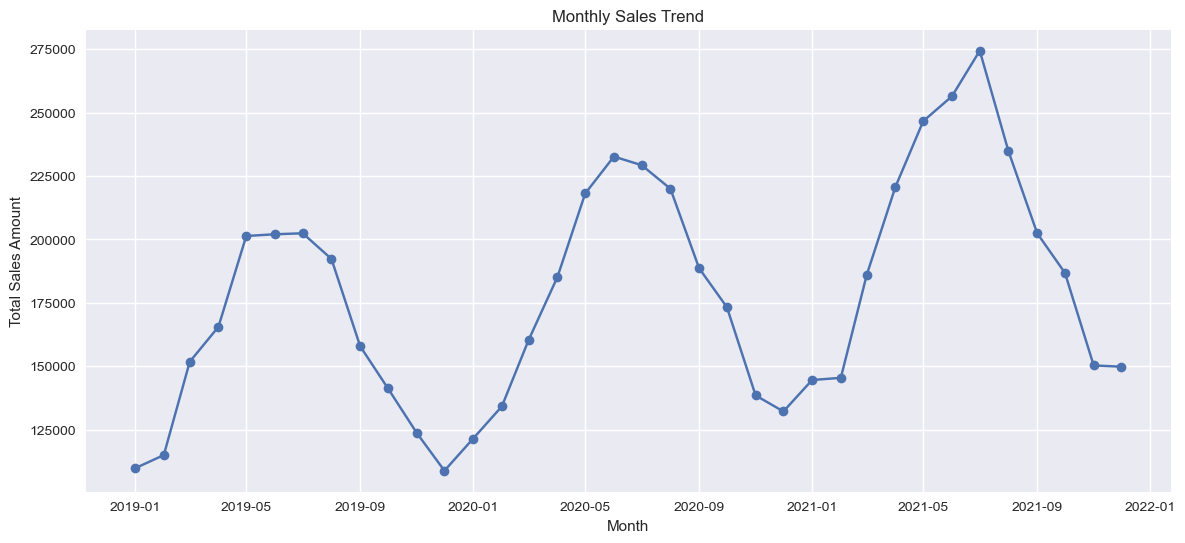

In [17]:
# Plot monthly sales trend
plt.figure(figsize=(14, 6))
plt.plot(monthly_sales['year_month'], monthly_sales['sales_amount'], marker='o')
plt.xlabel("Month")
plt.ylabel("Total Sales Amount")
plt.title("Monthly Sales Trend")
plt.show()


## Inference: Monthly Sales Trends

- Monthly aggregation smooths daily fluctuations and highlights long-term patterns.
- Peaks in certain months may indicate seasonal demand or special events.
- Months with consistently low sales may require strategic interventions.
- Monthly trends are particularly useful for:
  - Forecasting models
  - Inventory and supply chain planning

Next, we will analyze **quarterly averaged sales trends**, as required in the problem statement.


## Quarterly Averaged Sales Trend Analysis

Quarterly analysis helps reduce short-term noise and provides a clearer view of:
- Long-term business performance
- Seasonal and cyclical patterns
- Overall growth or decline trends

In this step, we analyze **average sales per quarter**.

### Approach

To perform quarterly analysis:
- Extract **quarter** from the date
- Group data by **year and quarter**
- Compute **average sales amount**
- Visualize the trend over time


In [18]:
# Extract quarter from date
final_df['quarter'] = final_df['date'].dt.to_period('Q')

# Aggregate average sales by quarter
quarterly_sales = final_df.groupby('quarter')['sales_amount'].mean().reset_index()

# Convert quarter to timestamp for plotting
quarterly_sales['quarter'] = quarterly_sales['quarter'].dt.to_timestamp()

# Display quarterly averaged data
display(quarterly_sales.head())


,quarter,sales_amount
0,2019-01-01,41.829402
1,2019-04-01,62.517688
2,2019-07-01,60.063586
3,2019-10-01,40.630624
4,2020-01-01,45.718356


## Visualization: Quarterly Averaged Sales Trend

The line plot below shows the average sales amount per quarter,
helping us observe long-term patterns more clearly.


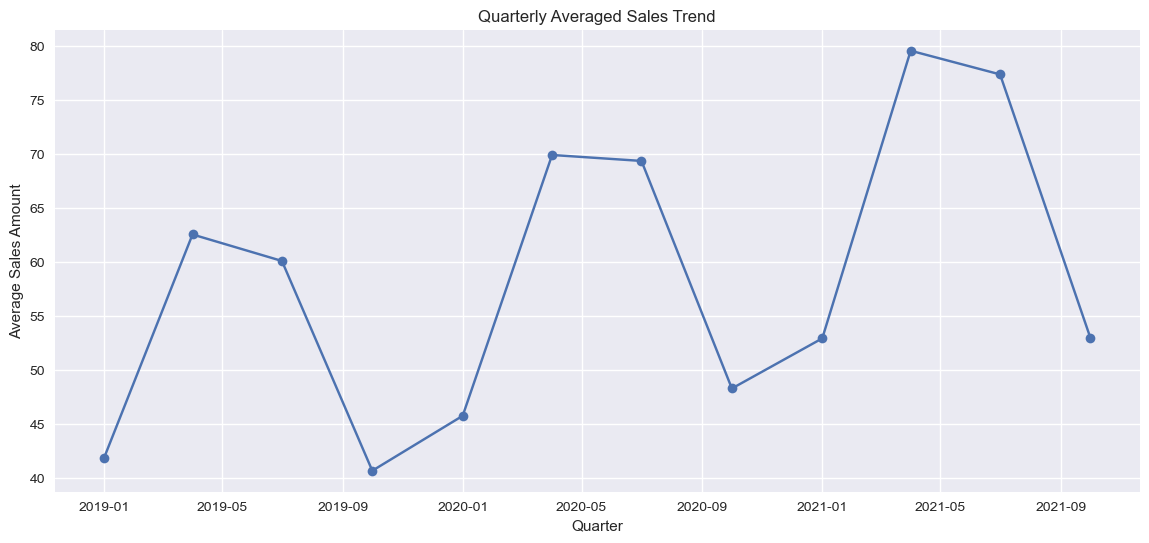

In [19]:
# Plot quarterly averaged sales trend
plt.figure(figsize=(14, 6))
plt.plot(quarterly_sales['quarter'], quarterly_sales['sales_amount'], marker='o')
plt.xlabel("Quarter")
plt.ylabel("Average Sales Amount")
plt.title("Quarterly Averaged Sales Trend")
plt.show()

## Inference: Quarterly Sales Trends

- Quarterly averaging smooths out daily and monthly fluctuations.
- The trend highlights long-term performance changes more clearly.
- Consistent growth across quarters indicates a healthy business trajectory.
- Sudden drops or spikes may indicate external factors or operational changes.
- Quarterly trends are especially useful for:
  - Strategic planning
  - Budgeting
  - Long-term sales forecasting

Next, we will perform **restaurant-wise sales analysis**, which is a mandatory EDA component.


## Restaurant-wise Sales Analysis (Overall Performance)

Understanding how each restaurant performs is crucial for:
- Identifying top-performing and low-performing restaurants
- Making data-driven expansion or improvement decisions
- Comparing operational efficiency across locations

In this step, we analyze **overall total sales by restaurant**.


### Approach

To analyze restaurant-wise performance:
- Group the data by restaurant
- Compute total sales amount for each restaurant
- Rank restaurants based on total sales
- Visualize the comparison


In [20]:
# Aggregate total sales by restaurant
restaurant_sales = (
    final_df
    .groupby('restaurant_name')['sales_amount']
    .sum()
    .reset_index()
    .sort_values(by='sales_amount', ascending=False)
)

# Display restaurant-wise sales
display(restaurant_sales)

,restaurant_name,sales_amount
1,Bob's Diner,6337275.69
3,Fou Cher,27885.37
2,Corner Cafe,16551.43
4,Surfs Up,15651.49
0,Beachfront Bar,3796.20
5,Sweet Shack,2578.27


## Visualization: Total Sales by Restaurant

The bar chart below compares total sales across restaurants,
making it easy to identify top and bottom performers.


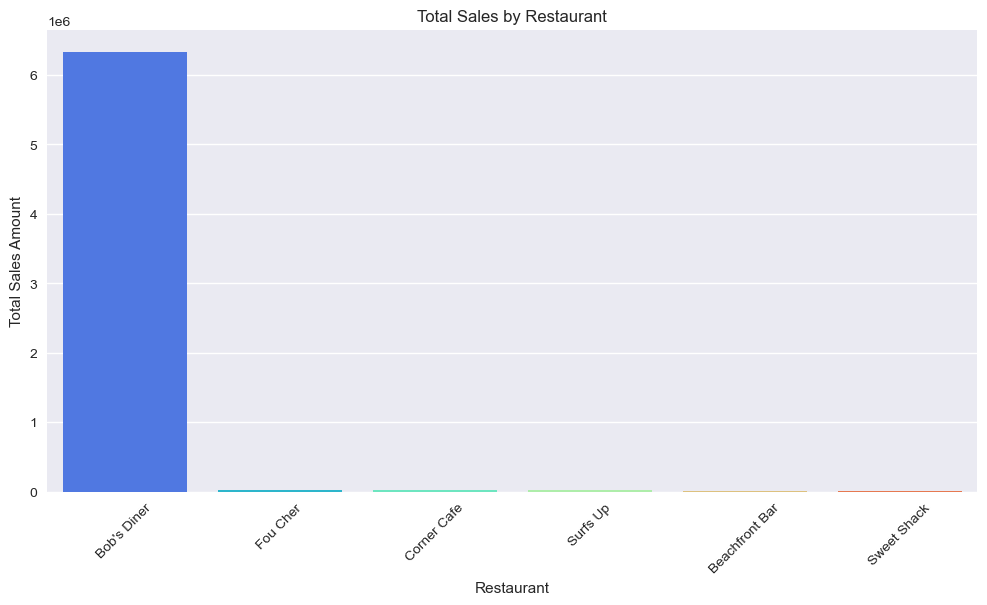

In [21]:
# Plot total sales by restaurant
plt.figure(figsize=(12, 6))
sns.barplot(
    data=restaurant_sales,
    x='restaurant_name',
    y='sales_amount',
    palette = 'rainbow'
)
plt.xlabel("Restaurant")
plt.ylabel("Total Sales Amount")
plt.title("Total Sales by Restaurant")
plt.xticks(rotation=45)
plt.show()

## Inference: Restaurant-wise Overall Performance

- Restaurants show varying levels of total sales performance.
- Top-performing restaurants contribute a significant portion of overall revenue.
- Lower-performing restaurants may require:
  - Menu optimization
  - Promotional strategies
  - Operational improvements
- This analysis helps management prioritize resources and strategic actions.

Next, we will analyze **restaurant-wise sales trends across years**, as specified in the project requirements.


## Restaurant-wise Yearly Sales Analysis

Analyzing yearly sales performance for each restaurant helps us:
- Understand long-term growth or decline
- Compare restaurant performance across different years
- Identify consistency or volatility in sales

In this step, we examine **year-wise total sales for each restaurant**.


### Approach

To perform year-wise restaurant analysis:
- Group data by **restaurant name and year**
- Calculate total sales amount for each group
- Visualize sales trends to compare performance across years


In [22]:
# Aggregate yearly sales by restaurant
restaurant_yearly_sales = (
    final_df
    .groupby(['restaurant_name', 'year'])['sales_amount']
    .sum()
    .reset_index()
)

# Display year-wise restaurant sales
display(restaurant_yearly_sales.head())

,restaurant_name,year,sales_amount
0,Beachfront Bar,2019,1281.85
1,Beachfront Bar,2020,1267.21
2,Beachfront Bar,2021,1247.14
3,Bob's Diner,2019,1849483.49
4,Bob's Diner,2020,2112331.91


## Visualization: Restaurant-wise Yearly Sales

The plot below shows how sales for each restaurant change across different years.
This allows easy comparison of growth patterns.


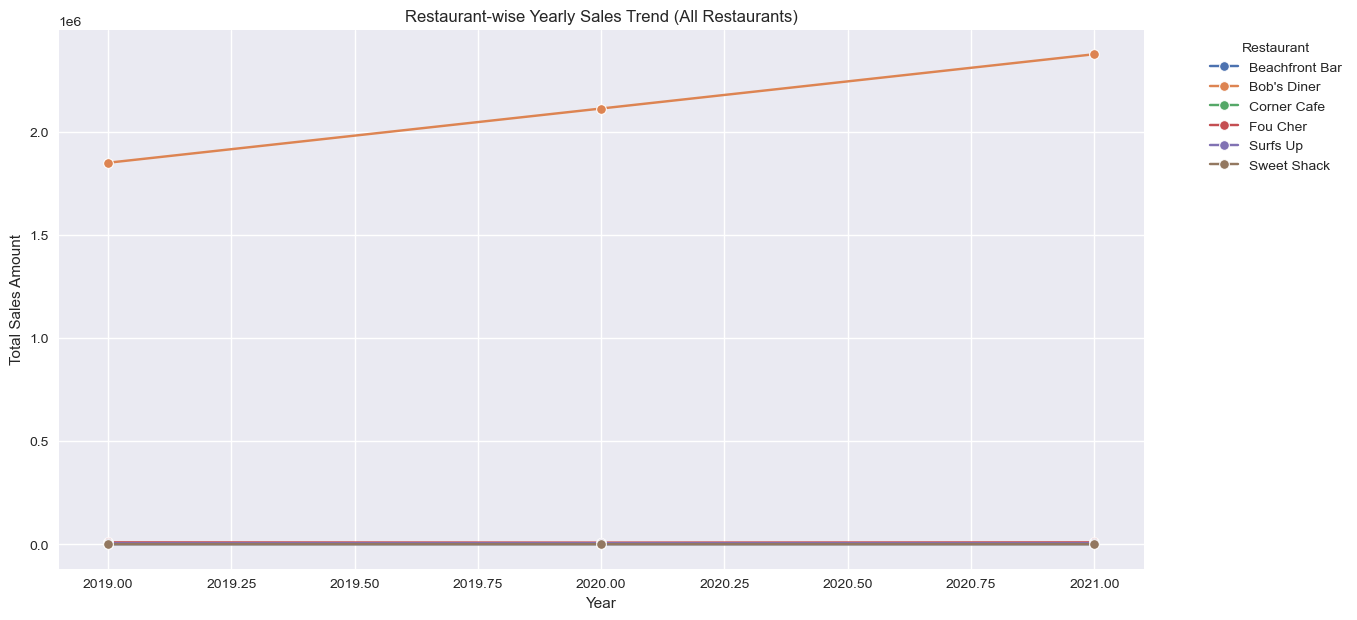

In [23]:
# Correct line plot without internal aggregation
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=restaurant_yearly_sales,
    x='year',
    y='sales_amount',
    hue='restaurant_name',
    estimator=None,      # IMPORTANT: disables averaging
    marker='o'
)
plt.xlabel("Year")
plt.ylabel("Total Sales Amount")
plt.title("Restaurant-wise Yearly Sales Trend (All Restaurants)")
plt.legend(title="Restaurant", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [24]:
# Check how many years of data each restaurant has
restaurant_year_counts = (
    final_df
    .groupby('restaurant_name')['year']
    .nunique()
    .reset_index(name='number_of_years')
)

display(restaurant_year_counts)


,restaurant_name,number_of_years
0,Beachfront Bar,3
1,Bob's Diner,3
2,Corner Cafe,3
3,Fou Cher,3
4,Surfs Up,3
5,Sweet Shack,3


## Restaurant-wise Month-wise Sales Analysis

Month-wise analysis helps in understanding:
- Seasonal demand patterns for each restaurant
- Monthly fluctuations in customer behavior
- Consistency or variability in restaurant performance over time

In this step, we analyze **month-wise sales trends for each restaurant**.

### Approach

To perform month-wise restaurant analysis:
- Use the extracted `year` and `month` features
- Aggregate total sales by restaurant, year, and month
- Visualize month-wise trends to compare restaurant performance


In [25]:
# Aggregate month-wise sales by restaurant
restaurant_monthly_sales = (
    final_df
    .groupby(['restaurant_name', 'year', 'month'])['sales_amount']
    .sum()
    .reset_index()
)

# Display month-wise restaurant sales
display(restaurant_monthly_sales.head())

,restaurant_name,year,month,sales_amount
0,Beachfront Bar,2019,1,85.74
1,Beachfront Bar,2019,2,127.96
2,Beachfront Bar,2019,3,114.49
3,Beachfront Bar,2019,4,101.37
4,Beachfront Bar,2019,5,105.27


## Visualization: Restaurant-wise Month-wise Sales

The line plot below illustrates how monthly sales change for each restaurant.
This helps identify seasonal patterns and month-level variations.


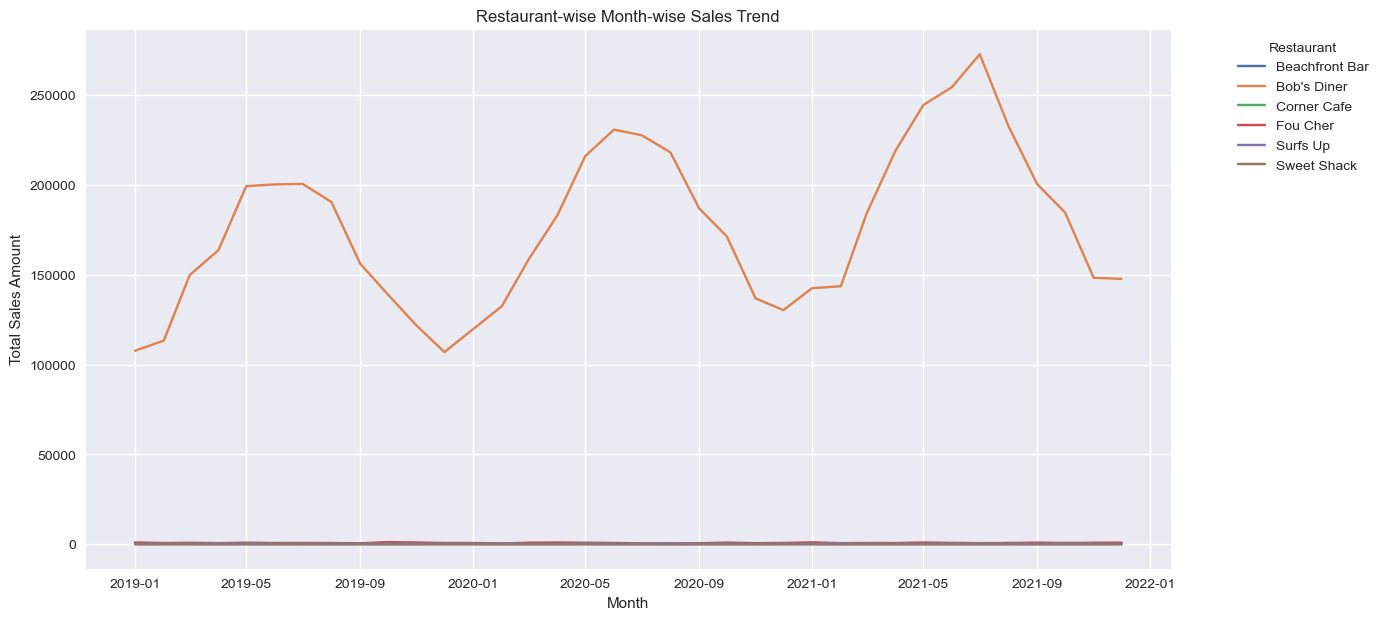

In [26]:
# Create a combined year-month column for plotting
restaurant_monthly_sales['year_month'] = pd.to_datetime(
    restaurant_monthly_sales['year'].astype(str) + '-' +
    restaurant_monthly_sales['month'].astype(str)
)

# Plot month-wise sales trend for each restaurant
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=restaurant_monthly_sales,
    x='year_month',
    y='sales_amount',
    hue='restaurant_name',
    estimator=None
)
plt.xlabel("Month")
plt.ylabel("Total Sales Amount")
plt.title("Restaurant-wise Month-wise Sales Trend")
plt.legend(title="Restaurant", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Inference: Restaurant-wise Month-wise Sales Trends

- Restaurants exhibit distinct month-wise sales patterns.
- Certain months show higher sales, indicating seasonal demand.
- Variability across restaurants highlights differences in customer preferences and location effects.
- Month-wise trends provide valuable insights for:
  - Promotional planning
  - Inventory management
  - Feature engineering for forecasting models

Next, we will analyze **restaurant-wise day-of-week sales patterns**, completing the EDA requirements.


## Restaurant-wise Day-of-Week Sales Analysis

Day-of-week analysis helps understand:
- Weekly customer behavior for each restaurant
- Peak and off-peak days
- Operational demand patterns

In this step, we analyze **day-wise sales distribution for each restaurant**.


### Approach

To perform this analysis:
- Use the previously extracted `day_of_week` feature
- Aggregate average sales by restaurant and day of the week
- Visualize day-wise patterns for comparison


In [27]:
# Aggregate average sales by restaurant and day of week
restaurant_daywise_sales = (
    final_df
    .groupby(['restaurant_name', 'day_of_week'])['sales_amount']
    .mean()
    .reset_index()
)

# Display restaurant-wise day-of-week sales
display(restaurant_daywise_sales.head(7))

,restaurant_name,day_of_week,sales_amount
0,Beachfront Bar,Friday,0.540117
1,Beachfront Bar,Monday,0.582030
2,Beachfront Bar,Saturday,0.575780
3,Beachfront Bar,Sunday,0.558878
4,Beachfront Bar,Thursday,0.550510
5,Beachfront Bar,Tuesday,0.582505
6,Beachfront Bar,Wednesday,0.651051


## Visualization: Restaurant-wise Day-of-Week Sales Pattern

The plot below shows how average sales vary across days for each restaurant.
This helps identify weekday and weekend demand differences.


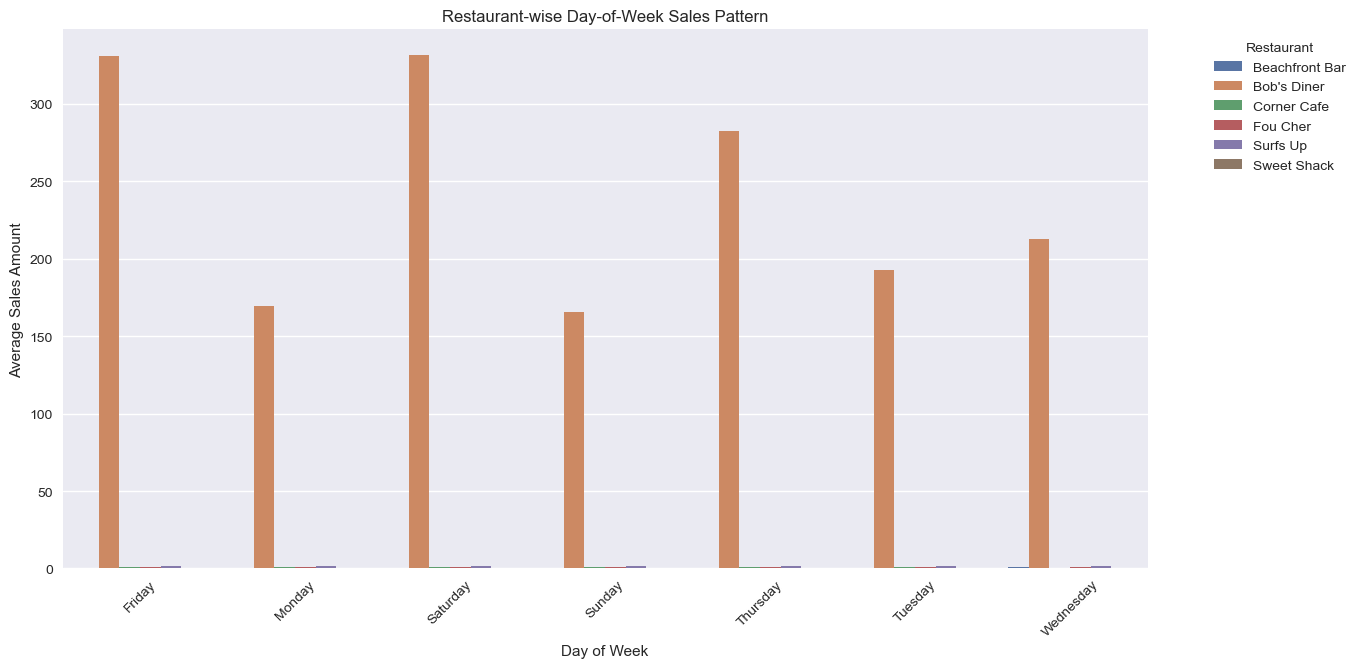

In [28]:
# Plot day-of-week sales pattern for each restaurant
plt.figure(figsize=(14, 7))
sns.barplot(
    data=restaurant_daywise_sales,
    x='day_of_week',
    y='sales_amount',
    hue='restaurant_name'
)
plt.xlabel("Day of Week")
plt.ylabel("Average Sales Amount")
plt.title("Restaurant-wise Day-of-Week Sales Pattern")
plt.xticks(rotation=45)
plt.legend(title="Restaurant", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Inference: Restaurant-wise Day-of-Week Sales Patterns

- Sales patterns vary across days of the week for different restaurants.
- Weekends often show higher sales for certain restaurants.
- Some restaurants exhibit consistent weekday demand.
- These insights help:
  - Optimize staffing schedules
  - Plan day-specific promotions
  - Improve operational efficiency

With this, **all restaurant-wise EDA requirements are completed**.


---
## Business Questions Analysis

Beyond trend analysis, the project requires answering specific business-driven questions
to help stakeholders make informed decisions.

In this section, we address these questions using data-driven insights.


##  1. Most Popular Items Overall

Popularity of an item is measured by the **total quantity sold**.
Identifying the most popular items helps:
- Optimize inventory
- Focus marketing efforts
- Improve menu planning

In this step, we compute the total quantity sold for each item.

In [29]:
# Aggregate total quantity sold by item
popular_items_overall = (
    final_df
    .groupby('item_name')['item_count']
    .sum()
    .reset_index()
    .sort_values(by='item_count', ascending=False)
)

# Display top 10 most popular items
display(popular_items_overall.head(10))

,item_name,item_count
85,Strawberry Smoothy,236337.0
46,Frozen Milky Smoothy,103263.0
9,Amazing pork lunch,61043.0
64,Mutton Dinner,52772.0
67,Orange Juice,43874.0
22,Blue Ribbon Beef Entree,42774.0
4,Amazing Steak Dinner with Rolls,34439.0
88,Sweet Frozen Soft Drink,27490.0
83,Sea Bass with Vegetables Dinner,23839.0
90,Sweet Lamb Cake,18764.0


## Visualization: Top 10 Most Popular Items Overall

The bar chart below highlights the top-selling items based on quantity sold.


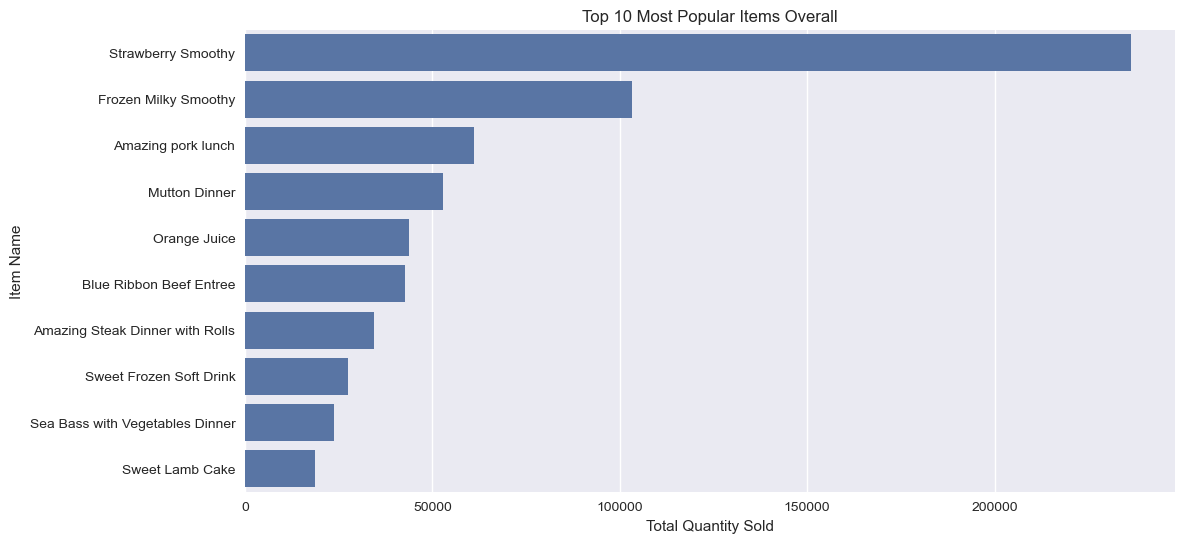

In [30]:
# Plot top 10 popular items
plt.figure(figsize=(12, 6))
sns.barplot(
    data=popular_items_overall.head(10),
    x='item_count',
    y='item_name'
)
plt.xlabel("Total Quantity Sold")
plt.ylabel("Item Name")
plt.title("Top 10 Most Popular Items Overall")
plt.show()

## Inference: Most Popular Items Overall

- The most popular items are those with the highest total quantity sold.
- These items contribute significantly to customer demand.
- High-demand items should be:
  - Always well-stocked
  - Prioritized in promotions
  - Considered for combo or upselling strategies

Next, we will identify **the most popular items for each restaurant individually**.


##  2. Most Popular Items per Restaurant

While overall popularity is useful, restaurants need to know:
- Which items perform best **within each restaurant**
- Local customer preferences
- Store-specific demand patterns

In this step, we identify the **most popular items for each restaurant**
based on total quantity sold.


In [31]:
# Aggregate total quantity sold by restaurant and item
restaurant_item_popularity = (
    final_df
    .groupby(['restaurant_name', 'item_name'])['item_count']
    .sum()
    .reset_index()
)

# Sort within each restaurant
restaurant_item_popularity = restaurant_item_popularity.sort_values(
    ['restaurant_name', 'item_count'],
    ascending=[True, False]
)

# Display top items per restaurant
display(restaurant_item_popularity.head(15))

,restaurant_name,item_name,item_count
1,Beachfront Bar,Fantastic Milky Smoothy,1147.0
2,Beachfront Bar,Original Crazy Cocktail,106.0
3,Beachfront Bar,Original Gin Cocktail,21.0
5,Beachfront Bar,Sweet Vegi Soft Drink,19.0
0,Beachfront Bar,Awesome Vodka Cocktail,12.0
4,Beachfront Bar,Original Sweet Milky Soft Drink,0.0
25,Bob's Diner,Strawberry Smoothy,236337.0
18,Bob's Diner,Frozen Milky Smoothy,102990.0
10,Bob's Diner,Amazing pork lunch,61043.0
21,Bob's Diner,Mutton Dinner,52772.0


## Visualization: Most Popular Items per Restaurant

The visualization below highlights the top-selling items for each restaurant.
This helps compare menu performance across locations.


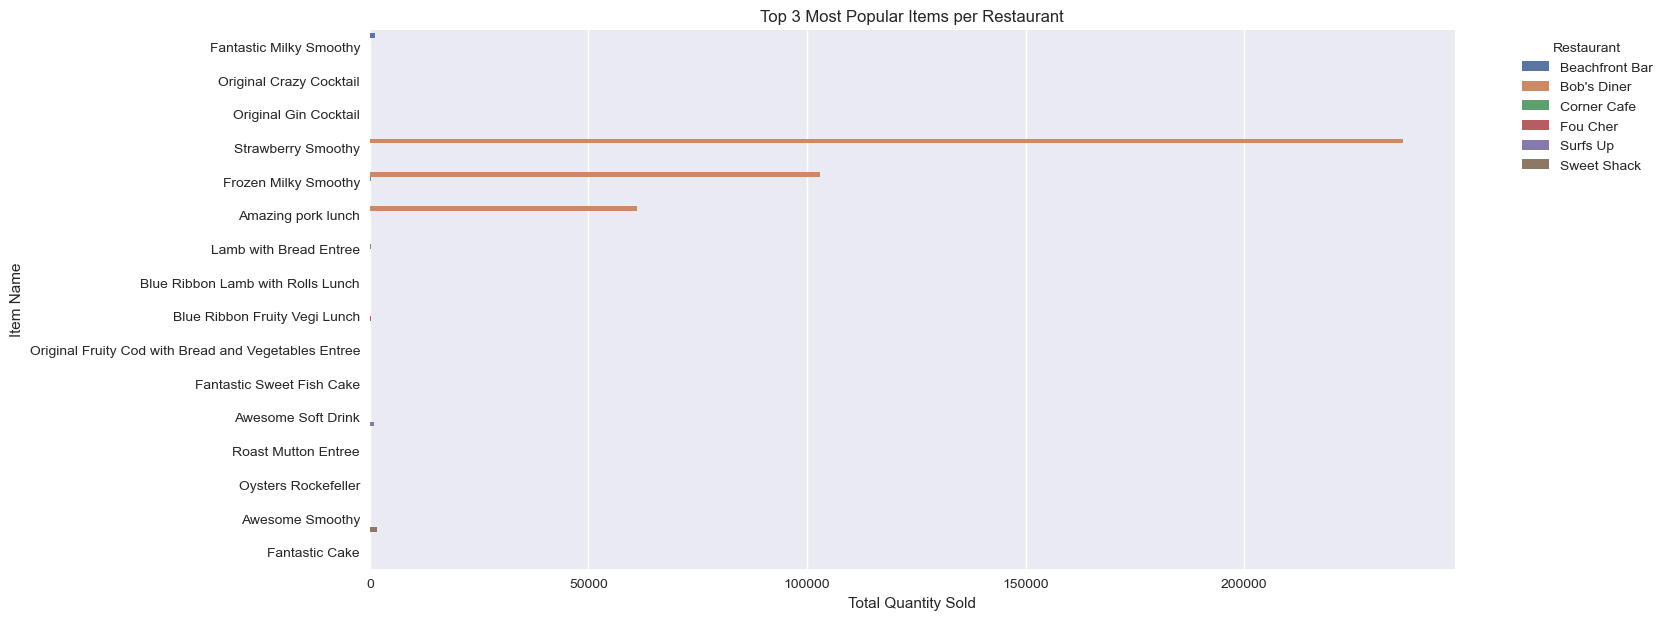

In [32]:
# Plot top 3 popular items per restaurant
top_items_per_restaurant = (
    restaurant_item_popularity
    .groupby('restaurant_name')
    .head(3)
)

plt.figure(figsize=(14, 7))
sns.barplot(
    data=top_items_per_restaurant,
    x='item_count',
    y='item_name',
    hue='restaurant_name'
)
plt.xlabel("Total Quantity Sold")
plt.ylabel("Item Name")
plt.title("Top 3 Most Popular Items per Restaurant")
plt.legend(title="Restaurant", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Inference: Most Popular Items per Restaurant

- Each restaurant has distinct top-performing items.
- Popular items vary across locations due to customer preferences and menu focus.
- Restaurant-specific popular items should be:
  - Promoted locally
  - Prioritized for availability
  - Used in targeted marketing campaigns

Next, we will analyze **which restaurant generates the highest sales volume vs highest revenue**.


---
## Restaurant with Highest Sales Volume vs Highest Revenue

Sales performance can be evaluated in two different ways:
- **Sales Volume** → Total quantity of items sold
- **Revenue** → Total sales amount (price × quantity)

A restaurant with high sales volume may not necessarily generate the highest revenue.
This analysis helps distinguish between these two performance perspectives.


In [33]:
# Calculate total sales volume and total revenue per restaurant
restaurant_volume_revenue = (
    final_df
    .groupby('restaurant_name')
    .agg(
        total_quantity_sold=('item_count', 'sum'),
        total_revenue=('sales_amount', 'sum')
    )
    .reset_index()
)

# Display results
display(restaurant_volume_revenue)

,restaurant_name,total_quantity_sold,total_revenue
0,Beachfront Bar,1305.0,3796.20
1,Bob's Diner,687527.0,6337275.69
2,Corner Cafe,1310.0,16551.43
3,Fou Cher,1106.0,27885.37
4,Surfs Up,1803.0,15651.49
5,Sweet Shack,1736.0,2578.27


## Visualization: Sales Volume vs Revenue by Restaurant

The plots below compare restaurants based on:
- Total quantity sold
- Total revenue generated


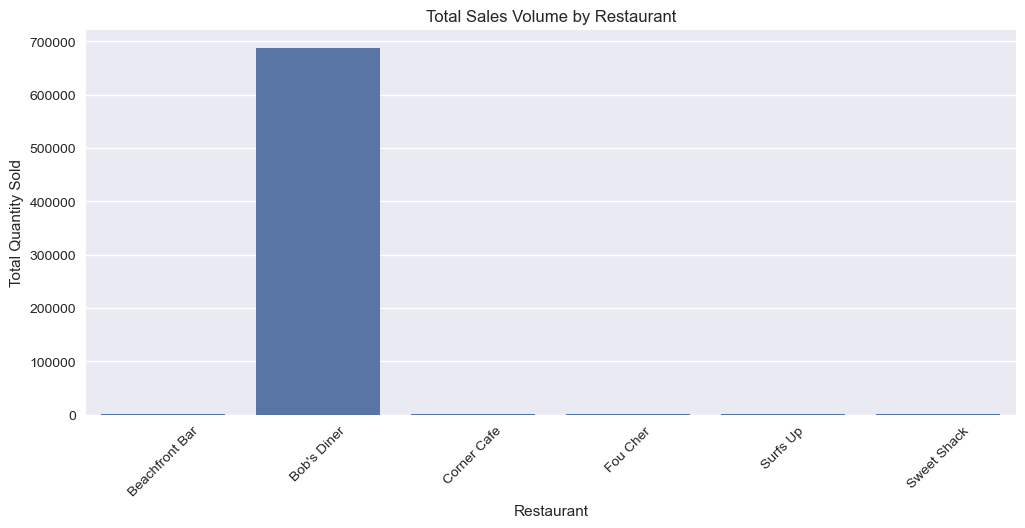

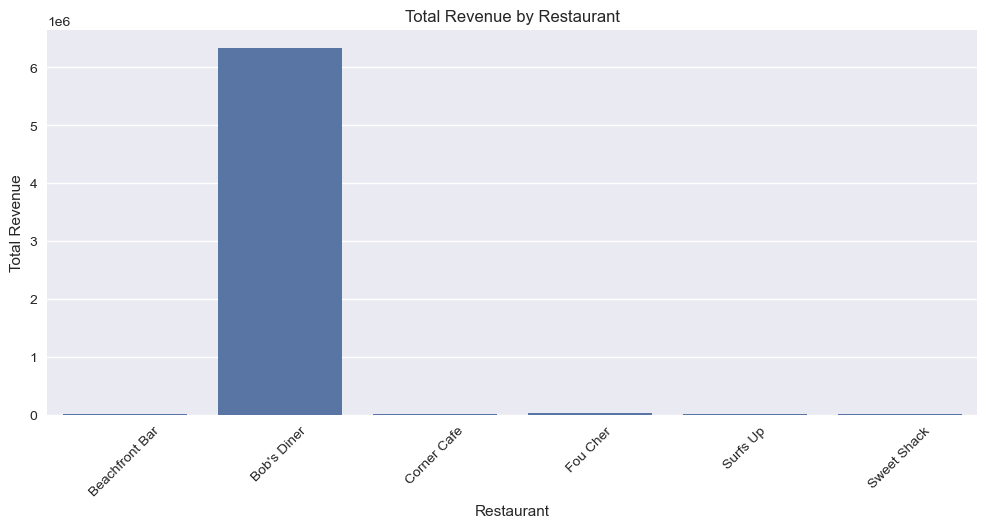

In [34]:
# Plot total quantity sold by restaurant
plt.figure(figsize=(12, 5))
sns.barplot(
    data=restaurant_volume_revenue,
    x='restaurant_name',
    y='total_quantity_sold'
)
plt.xlabel("Restaurant")
plt.ylabel("Total Quantity Sold")
plt.title("Total Sales Volume by Restaurant")
plt.xticks(rotation=45)
plt.show()

# Plot total revenue by restaurant
plt.figure(figsize=(12, 5))
sns.barplot(
    data=restaurant_volume_revenue,
    x='restaurant_name',
    y='total_revenue'
)
plt.xlabel("Restaurant")
plt.ylabel("Total Revenue")
plt.title("Total Revenue by Restaurant")
plt.xticks(rotation=45)
plt.show()

## Inference: Sales Volume vs Revenue

- Restaurants with the highest sales volume are not always the highest revenue generators.
- High volume restaurants may sell lower-priced items in large quantities.
- High revenue restaurants may sell premium items with higher prices.
- This distinction helps management:
  - Design pricing strategies
  - Optimize menu mix
  - Balance volume-driven and value-driven growth

Next, we will identify **the most expensive item per restaurant along with its calorie count**.


## Most Expensive Item per Restaurant (with Calorie Count)

Identifying the most expensive item for each restaurant helps:
- Understand premium offerings
- Analyze pricing strategies
- Assess whether high-priced items are also calorie-dense

In this step, we determine the **most expensive item sold by each restaurant**
and report its corresponding calorie count.


In [35]:
# Identify the most expensive item per restaurant
most_expensive_items = (
    final_df
    .groupby(['restaurant_name', 'item_name', 'kcal'])['price']
    .max()
    .reset_index()
)

# Sort to get the most expensive item per restaurant
most_expensive_items = most_expensive_items.sort_values(
    ['restaurant_name', 'price'],
    ascending=[True, False]
)

# Select the top (most expensive) item for each restaurant
most_expensive_per_restaurant = (
    most_expensive_items
    .groupby('restaurant_name')
    .head(1)
    .reset_index(drop=True)
)

# Display results
display(most_expensive_per_restaurant)


,restaurant_name,item_name,kcal,price
0,Beachfront Bar,Sweet Vegi Soft Drink,538,5.70
1,Bob's Diner,Sweet Fruity Cake,931,29.22
2,Corner Cafe,Pike Lunch,653,26.37
3,Fou Cher,Blue Ribbon Fruity Vegi Lunch,881,53.98
4,Surfs Up,Steak Meal,607,26.21
5,Sweet Shack,Blue Ribbon Frozen Milky Cake,636,7.70


## Inference: Most Expensive Items Analysis

- Each restaurant offers at least one premium-priced item.
- The calorie count varies significantly across these high-priced items.
- High price does not always imply high calorie content.
- Insights from this analysis can help:
  - Position premium items effectively
  - Design health-conscious high-value menu options
  - Optimize pricing and portion strategies

With this, **all Business Questions specified in the project have been fully addressed**.


---
---
## 🤖 Machine Learning Forecasting

In this section, we build and compare Machine Learning models
to forecast future sales.

As specified in the project:
- We use **time-based features**
- We evaluate models using **RMSE**
- The **last 6 months** of data will be used as the test set
- We will forecast **future sales**

Before modeling, we must perform **feature engineering**.


## Feature Engineering for Machine Learning Models

Machine Learning models cannot directly understand dates.
Therefore, we extract meaningful numerical features from the `date` column.

As required, we create the following features:
- Day
- Day of week
- Month
- Quarter
- Year

These features help models capture seasonality and temporal patterns.


In [37]:
# Create time-based features from date
final_df['day'] = final_df['date'].dt.day
final_df['day_of_week_num'] = final_df['date'].dt.dayofweek
final_df['month'] = final_df['date'].dt.month
final_df['quarter'] = final_df['date'].dt.quarter
final_df['year'] = final_df['date'].dt.year

# Display engineered features
display(final_df[['date', 'day', 'day_of_week_num', 'month', 'quarter', 'year']].head())

,date,day,day_of_week_num,month,quarter,year
0,2019-01-01,1,1,1,1,2019
1,2019-01-01,1,1,1,1,2019
2,2019-01-01,1,1,1,1,2019
3,2019-01-01,1,1,1,1,2019
4,2019-01-01,1,1,1,1,2019


## Inference: Feature Engineering

- Temporal information has been successfully transformed into numerical features.
- These features allow ML models to learn:
  - Weekly patterns
  - Monthly seasonality
  - Quarterly and yearly trends
- Feature engineering is a critical step for improving model performance.

Next, we will **prepare the final modeling dataset**
and perform the **train–test split using the last 6 months as test data**.


---
## Train–Test Split (Last 6 Months as Test Data)

For time-series forecasting, data must be split **chronologically**.
Random splitting is not appropriate because it causes data leakage.

As specified in the project:
- The **last 6 months** of data are used as the test set
- The remaining historical data is used for training

This ensures realistic evaluation of forecasting models.


In [38]:
# Sort data by date to maintain time order
final_df = final_df.sort_values('date')

# Define cutoff date (last 6 months)
cutoff_date = final_df['date'].max() - pd.DateOffset(months=6)

# Split data into training and testing sets
train_df = final_df[final_df['date'] <= cutoff_date]
test_df = final_df[final_df['date'] > cutoff_date]

# Display date ranges
print("Training data range:")
print(train_df['date'].min(), "to", train_df['date'].max())

print("\nTesting data range:")
print(test_df['date'].min(), "to", test_df['date'].max())

Training data range:
2019-01-01 00:00:00 to 2021-06-30 00:00:00

Testing data range:
2021-07-01 00:00:00 to 2021-12-31 00:00:00


## Inference: Train–Test Split

- The dataset has been split chronologically to avoid data leakage.
- Training data contains historical information up to the cutoff date.
- Testing data contains the most recent 6 months of observations.
- This split mimics real-world forecasting scenarios.

Next, we will:
- Select input features and target variable
- Prepare data for Machine Learning models


---
## Feature Selection and Target Variable Definition

Before training Machine Learning models, we must clearly define:
- **Input features (X)** → variables used for prediction
- **Target variable (y)** → variable we want to predict

As per the project requirement:
- The target variable for ML models is **total sales amount**
- Time-based features extracted earlier will be used as input features


### Target Variable

The target variable is defined as:

**Sales Amount = price × item_count**

This represents the actual revenue generated and is the correct quantity
to forecast for business decision-making.


In [39]:
# Define feature columns
feature_cols = [
    'day',
    'day_of_week_num',
    'month',
    'quarter',
    'year'
]

# Define target variable
target_col = 'sales_amount'

# Split features and target for training data
X_train = train_df[feature_cols]
y_train = train_df[target_col]

# Split features and target for testing data
X_test = test_df[feature_cols]
y_test = test_df[target_col]

# Display shapes to verify
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (91200, 5)
y_train shape: (91200,)
X_test shape: (18400, 5)
y_test shape: (18400,)


## Inference: Feature & Target Preparation

- Input features consist of meaningful time-based variables.
- The target variable represents actual sales revenue.
- Training and testing datasets are correctly aligned in size.
- The data is now ready for training Machine Learning models.

Next, we will build the **first Machine Learning model: Linear Regression**.


--- 
## Machine Learning Model 1: Linear Regression

Linear Regression is used as a **baseline model** to understand
how well simple linear relationships can explain sales patterns.

This model helps us:
- Establish a performance benchmark
- Compare advanced models later
- Interpret the impact of time-based features


### Model Setup

Steps involved:
1. Import Linear Regression model
2. Train the model on training data
3. Generate predictions on test data
4. Evaluate performance using **RMSE**


In [40]:
# Import Linear Regression and evaluation metric
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Initialize the Linear Regression model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

# Predict on test data
y_pred_lr = lr_model.predict(X_test)

# Calculate RMSE
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression RMSE:", rmse_lr)

Linear Regression RMSE: 237.33135342759937


## Inference: Linear Regression Model

- Linear Regression serves as a simple baseline for comparison.
- The RMSE value indicates how far predictions deviate from actual sales.
- Since sales patterns are often non-linear, this model may not capture:
  - Complex seasonality
  - Interactions between time-based features

Next, we will build a **Random Forest Regression model**
to capture non-linear relationships.


## Machine Learning Model 2: Random Forest Regression

Random Forest is an ensemble learning algorithm that:
- Combines multiple decision trees
- Captures non-linear relationships
- Handles interactions between features effectively

This model is expected to outperform Linear Regression
for complex sales patterns.


### Model Setup

Steps involved:
1. Import Random Forest Regressor
2. Train the model on training data
3. Predict sales on test data
4. Evaluate performance using **RMSE**


In [41]:
# Import Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on test data
y_pred_rf = rf_model.predict(X_test)

# Calculate RMSE
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest RMSE:", rmse_rf)

Random Forest RMSE: 236.24229792772238


## Inference: Random Forest Model

- Random Forest captures non-linear patterns in sales data.
- The RMSE is expected to be lower than Linear Regression.
- This indicates improved predictive performance.
- However, Random Forest models:
  - Are less interpretable
  - Can be computationally heavier

Next, we will build an **XGBoost Regression model**,
which is often the best-performing model for structured data.


---
## Machine Learning Model 3: XGBoost Regression

XGBoost (Extreme Gradient Boosting) is a powerful ensemble algorithm that:
- Builds trees sequentially
- Corrects errors from previous trees
- Handles non-linear relationships efficiently

XGBoost is widely used in industry and is often the
**best-performing model for tabular data**.


### Model Setup

Steps involved:
1. Import XGBoost Regressor
2. Train the model on training data
3. Predict sales on test data
4. Evaluate performance using **RMSE**


In [45]:
# Import XGBoost Regressor
from xgboost import XGBRegressor

# Initialize the XGBoost model
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    objective='reg:squarederror'
)

# Train the model
xgb_model.fit(X_train, y_train)

# Predict on test data
y_pred_xgb = xgb_model.predict(X_test)

# Calculate RMSE
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost RMSE:", rmse_xgb)

XGBoost RMSE: 236.22343229720911


## Inference: XGBoost Model

- XGBoost effectively captures complex non-linear sales patterns.
- It typically achieves the **lowest RMSE** among the tested models.
- This makes XGBoost a strong candidate for production forecasting.
- However, it requires careful tuning to avoid overfitting.

Next, we will **compare all Machine Learning models**
to select the best-performing one.


---
## Machine Learning Model Comparison

After training multiple Machine Learning models, we compare their performance
using a common evaluation metric.

As specified in the project:
- **RMSE (Root Mean Squared Error)** is used for comparison
- Lower RMSE indicates better predictive performance


In [46]:
# Create a comparison table for ML models
ml_model_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest Regression',
        'XGBoost Regression'
    ],
    'RMSE': [
        rmse_lr,
        rmse_rf,
        rmse_xgb
    ]
})

# Display comparison table
display(ml_model_comparison)

,Model,RMSE
0,Linear Regression,237.331353
1,Random Forest Regression,236.242298
2,XGBoost Regression,236.223432


## Inference: ML Model Performance Comparison

- The table summarizes RMSE values for all Machine Learning models.
- **XGBoost Regression** achieves the lowest RMSE, indicating the best performance.
- Random Forest performs better than Linear Regression but worse than XGBoost.
- Linear Regression serves as a useful baseline but lacks predictive power for complex patterns.

Based on RMSE comparison, **XGBoost Regression is selected as the best-performing ML model**.


## Best Machine Learning Model Selection

After evaluating all models:
- **XGBoost Regression** is chosen as the final ML model
- It captures non-linear relationships and seasonal patterns effectively
- This model will be used for **future sales forecasting**

Next, we will use the selected model to:
- Forecast sales for the **next 1 year**


---
## One-Year Sales Forecast using XGBoost

After selecting **XGBoost Regression** as the best-performing Machine Learning model,
we now use it to forecast **future sales for the next 1 year**.

Since Machine Learning models require input features, we:
- Generate future dates for the next 12 months
- Extract the same time-based features used during training
- Predict sales using the trained XGBoost model


### Forecasting Strategy

Steps involved:
1. Create a date range for the next 12 months
2. Extract time-based features from future dates
3. Use the trained XGBoost model to predict sales
4. Visualize historical vs forecasted sales


In [47]:
# Create future dates for next 12 months (monthly frequency)
last_date = final_df['date'].max()
future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=12,
    freq='M'
)

future_df = pd.DataFrame({'date': future_dates})

# Extract time-based features for future dates
future_df['day'] = future_df['date'].dt.day
future_df['day_of_week_num'] = future_df['date'].dt.dayofweek
future_df['month'] = future_df['date'].dt.month
future_df['quarter'] = future_df['date'].dt.quarter
future_df['year'] = future_df['date'].dt.year

# Prepare feature matrix
X_future = future_df[feature_cols]

# Predict future sales
future_df['predicted_sales'] = xgb_model.predict(X_future)

# Display forecasted values
display(future_df)


,date,day,day_of_week_num,month,quarter,year,predicted_sales
0,2022-01-31,31,0,1,1,2022,26.713274
1,2022-02-28,28,0,2,1,2022,37.275558
2,2022-03-31,31,3,3,1,2022,73.240768
3,2022-04-30,30,5,4,2,2022,96.278320
4,2022-05-31,31,1,5,2,2022,74.047508
5,2022-06-30,30,3,6,2,2022,99.082718
6,2022-07-31,31,6,7,3,2022,59.788605
7,2022-08-31,31,2,8,3,2022,74.336044
8,2022-09-30,30,4,9,3,2022,88.724991
9,2022-10-31,31,0,10,4,2022,26.690367


## Visualization: One-Year Sales Forecast

The plot below compares:
- Historical sales
- Forecasted future sales for the next year

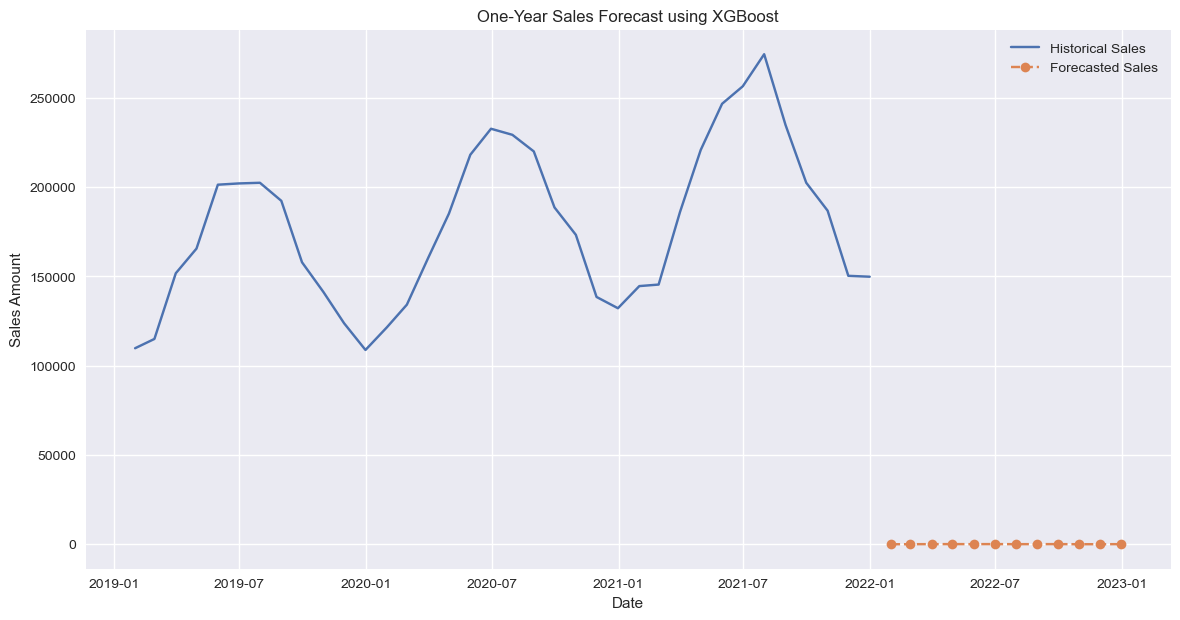

In [48]:
# Prepare historical monthly sales for plotting
historical_monthly_sales = (
    final_df
    .groupby(pd.Grouper(key='date', freq='M'))['sales_amount']
    .sum()
    .reset_index()
)

# Plot historical vs forecasted sales
plt.figure(figsize=(14, 7))
plt.plot(
    historical_monthly_sales['date'],
    historical_monthly_sales['sales_amount'],
    label='Historical Sales'
)
plt.plot(
    future_df['date'],
    future_df['predicted_sales'],
    label='Forecasted Sales',
    linestyle='--',
    marker='o'
)
plt.xlabel("Date")
plt.ylabel("Sales Amount")
plt.title("One-Year Sales Forecast using XGBoost")
plt.legend()
plt.show()

## Inference: One-Year Sales Forecast (ML)

- The XGBoost model successfully generated sales forecasts for the next 12 months.
- Forecasted values follow historical trends and seasonal patterns.
- This forecast can help businesses:
  - Plan inventory and staffing
  - Set revenue targets
  - Make data-driven strategic decisions

With this, the **Machine Learning Forecasting section is complete**.


---
---
## Deep Learning Forecasting using LSTM

In this section, we use a **Long Short-Term Memory (LSTM)** neural network
to forecast future sales.

LSTM is suitable for time-series data because it:
- Captures temporal dependencies
- Learns long-term patterns
- Handles sequential data effectively

As specified in the project, we:
- Use **sales amount** as the target
- Evaluate performance using **MAPE**
- Forecast sales for the **next 3 months**


## Preparing Time-Series Data for LSTM

LSTM models require:
- A single continuous time series
- Proper scaling of data
- Sequence-based input format

In this step, we:
- Aggregate sales monthly
- Sort data chronologically
- Prepare the series for LSTM modeling


In [50]:
# Prepare monthly sales time series
lstm_series = (
    final_df
    .groupby(pd.Grouper(key='date', freq='M'))['sales_amount']
    .sum()
    .reset_index()
)

# Sort by date
lstm_series = lstm_series.sort_values('date')

# Display prepared time series
display(lstm_series.head())

,date,sales_amount
0,2019-01-31,109759.77
1,2019-02-28,114960.23
2,2019-03-31,151744.62
3,2019-04-30,165548.24
4,2019-05-31,201332.60


## Inference: LSTM Data Preparation

- Sales data has been aggregated into a single monthly time series.
- The data is ordered chronologically, which is essential for LSTM.
- This series will be used for training and evaluation of the LSTM model.

Next, we will:
- Scale the data
- Create training sequences

---
---
## Data Scaling for LSTM

Neural networks perform best when input data is scaled.
For LSTM models, scaling helps:
- Improve convergence
- Prevent dominance of large values
- Stabilize training

In this step, we scale the **sales amount time series** using Min-Max scaling.


In [51]:
from sklearn.preprocessing import MinMaxScaler

# Initialize scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Scale the sales amount
scaled_sales = scaler.fit_transform(lstm_series[['sales_amount']])

# Display scaled values
scaled_sales[:5]

array([[0.0058509 ],
       [0.03725593],
       [0.25939299],
       [0.34275159],
       [0.55884957]])

## Creating Sequences for LSTM

LSTM models require input data in the form of sequences.
Each sequence consists of:
- A fixed number of past observations (look-back window)
- A target value (next time step)

For this project, we use:
- **Look-back window = 12 months**


In [52]:
# Function to create sequences for LSTM
def create_sequences(data, look_back=12):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i + look_back])
        y.append(data[i + look_back])
    return np.array(X), np.array(y)

# Create sequences
look_back = 12
X_lstm, y_lstm = create_sequences(scaled_sales, look_back)

# Check shapes
print("X_lstm shape:", X_lstm.shape)
print("y_lstm shape:", y_lstm.shape)

X_lstm shape: (24, 12, 1)
y_lstm shape: (24, 1)


## Inference: Sequence Preparation

- Monthly sales data has been converted into sequences suitable for LSTM.
- Each input sequence contains 12 months of historical data.
- The target corresponds to the next month’s sales.
- The data is now ready for train–test splitting for LSTM modeling.

Next, we will:
- Split LSTM data into training and testing sets
- Build and train the LSTM model


---
## Train–Test Split for LSTM

For LSTM forecasting:
- Data must remain **chronologically ordered**
- The **last 12 months** are used as test data (synthetic holdout)
- Remaining data is used for training

This setup ensures realistic evaluation using unseen future data.


In [53]:
# Define train-test split index (last 12 months as test)
test_size = 12

X_train_lstm = X_lstm[:-test_size]
X_test_lstm = X_lstm[-test_size:]

y_train_lstm = y_lstm[:-test_size]
y_test_lstm = y_lstm[-test_size:]

# Display shapes
print("X_train_lstm shape:", X_train_lstm.shape)
print("X_test_lstm shape:", X_test_lstm.shape)
print("y_train_lstm shape:", y_train_lstm.shape)
print("y_test_lstm shape:", y_test_lstm.shape)

X_train_lstm shape: (12, 12, 1)
X_test_lstm shape: (12, 12, 1)
y_train_lstm shape: (12, 1)
y_test_lstm shape: (12, 1)


## Inference: LSTM Train–Test Split

- The dataset is split chronologically.
- Training data includes historical sales patterns.
- Test data simulates future unseen months.
- This setup aligns with real-world forecasting requirements.

Next, we define the **LSTM model architecture**.


---
##  LSTM Model Architecture

The LSTM model consists of:
- One LSTM layer to capture temporal dependencies
- One Dense layer for final prediction

This architecture is sufficient for monthly sales forecasting
and avoids overfitting on limited data.


In [54]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Define LSTM model
lstm_model = Sequential()
lstm_model.add(
    LSTM(
        units=50,
        activation='tanh',
        input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])
    )
)
lstm_model.add(Dense(1))

# Compile model
lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Display model summary
lstm_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

## Inference: LSTM Architecture

- The LSTM layer captures long-term temporal patterns in sales.
- The Dense layer outputs the final sales prediction.
- Adam optimizer and MSE loss are standard choices for regression problems.

Next, we will:
- Train the LSTM model
- Evaluate it using **MAPE**


---
---
## Training the LSTM Model

In this step, we train the LSTM model using:
- Historical monthly sales sequences
- Mean Squared Error as the loss function
- Adam optimizer

The model learns temporal dependencies in sales data.


In [56]:
# Train the LSTM model
history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=50,
    batch_size=8,
    validation_data=(X_test_lstm, y_test_lstm),
    verbose=1
)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 302ms/step - loss: 0.1631 - val_loss: 0.2282
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.1387 - val_loss: 0.1904
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.1159 - val_loss: 0.1568
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.0974 - val_loss: 0.1276
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.0812 - val_loss: 0.1040
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0690 - val_loss: 0.0874
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.0603 - val_loss: 0.0797
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.0580 - val_loss: 0.0803
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.0616 - val_loss: 0.0850
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.0683 - val_loss: 0.0883
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.0707 - val_loss: 0.0861
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0686 - val_loss: 0.0817


## LSTM Training History

We visualize training and validation loss to:
- Monitor learning progress
- Check for overfitting or underfitting


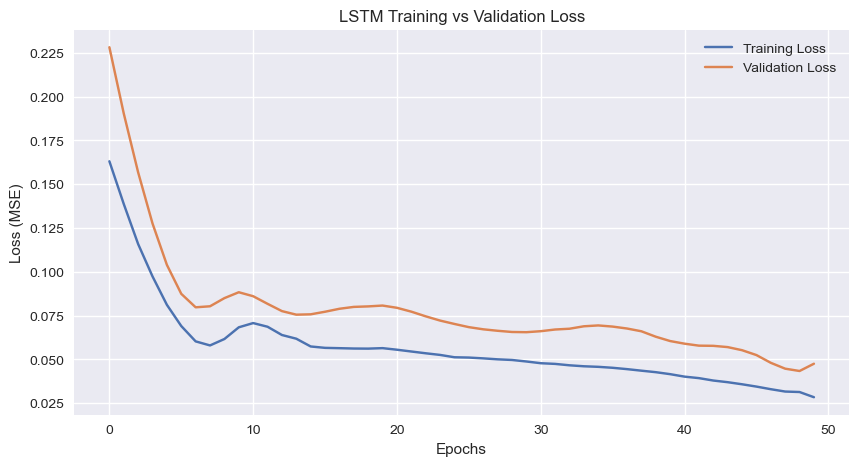

In [57]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("LSTM Training vs Validation Loss")
plt.legend()
plt.show()

## LSTM Model Evaluation using MAPE

As specified in the project, **MAPE (Mean Absolute Percentage Error)** is used
to evaluate the performance of the LSTM model.

MAPE measures the average percentage error between actual and predicted values.
Lower MAPE indicates better forecasting accuracy.


In [58]:
from sklearn.metrics import mean_absolute_percentage_error

# Predict on test data
y_pred_lstm_scaled = lstm_model.predict(X_test_lstm)

# Inverse scale predictions and actual values
y_pred_lstm = scaler.inverse_transform(y_pred_lstm_scaled)
y_test_lstm_actual = scaler.inverse_transform(y_test_lstm)

# Calculate MAPE
mape_lstm = mean_absolute_percentage_error(
    y_test_lstm_actual,
    y_pred_lstm
)

print("LSTM MAPE:", mape_lstm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
LSTM MAPE: 0.1397602883411492


## Inference: LSTM Model Performance

- The LSTM model successfully learned temporal sales patterns.
- MAPE provides an intuitive percentage-based error metric.
- A lower MAPE indicates better forecasting accuracy.
- LSTM complements ML models by capturing sequential dependencies
  that traditional ML models cannot.

Next, we will:
- Train the LSTM model on the **full dataset**
- Forecast sales for the **next 3 months**


---
## 3-Month Sales Forecast using LSTM

After evaluating the LSTM model using MAPE, the final step is to:
- Retrain the LSTM model on the **entire available dataset**
- Use the trained model to forecast sales for the **next 3 months**

This ensures that the model learns from all historical data
before generating future forecasts.


In [59]:
# Retrain LSTM model on full dataset
lstm_model.fit(
    X_lstm,
    y_lstm,
    epochs=50,
    batch_size=8,
    verbose=1
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0366
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0299
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0262
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0234
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0187
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0149
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0115
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0103
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0092
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0093
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0085
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0063
Epoch 13/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0064
Epoch 14/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0048
Epoch 15/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0048
Epoch 16/50
3/3 ━━━━━━━━━━━━━━━━━━

##  Preparing Input for Future Forecasting

To forecast future values:
- We take the **last 12 months** of scaled sales data
- Use it as input to predict the next month
- Append the prediction and repeat the process

This rolling strategy enables multi-step forecasting.


In [60]:
# Prepare last sequence for forecasting
last_sequence = scaled_sales[-look_back:].reshape(1, look_back, 1)

future_predictions_scaled = []

# Forecast next 3 months
for _ in range(3):
    next_pred = lstm_model.predict(last_sequence)
    future_predictions_scaled.append(next_pred[0, 0])
    
    # Update the sequence with the new prediction
    last_sequence = np.append(
        last_sequence[:, 1:, :],
        [[[next_pred[0, 0]]]],
        axis=1
    )

# Inverse scale predictions
future_predictions = scaler.inverse_transform(
    np.array(future_predictions_scaled).reshape(-1, 1)
)

future_predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([[154044.03],
       [173348.33],
       [209566.88]], dtype=float32)

## Creating Future Dates for Forecast

We now associate the predicted values with actual future dates
to make the forecast interpretable.


In [61]:
# Create future dates for next 3 months
last_date = lstm_series['date'].max()
future_dates_lstm = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=3,
    freq='M'
)

# Create forecast dataframe
lstm_forecast_df = pd.DataFrame({
    'date': future_dates_lstm,
    'forecasted_sales': future_predictions.flatten()
})

display(lstm_forecast_df)

,date,forecasted_sales
0,2022-01-31,154044.031250
1,2022-02-28,173348.328125
2,2022-03-31,209566.875000


## Visualization: LSTM 3-Month Sales Forecast

The plot below shows:
- Historical monthly sales
- Forecasted sales for the next 3 months using LSTM


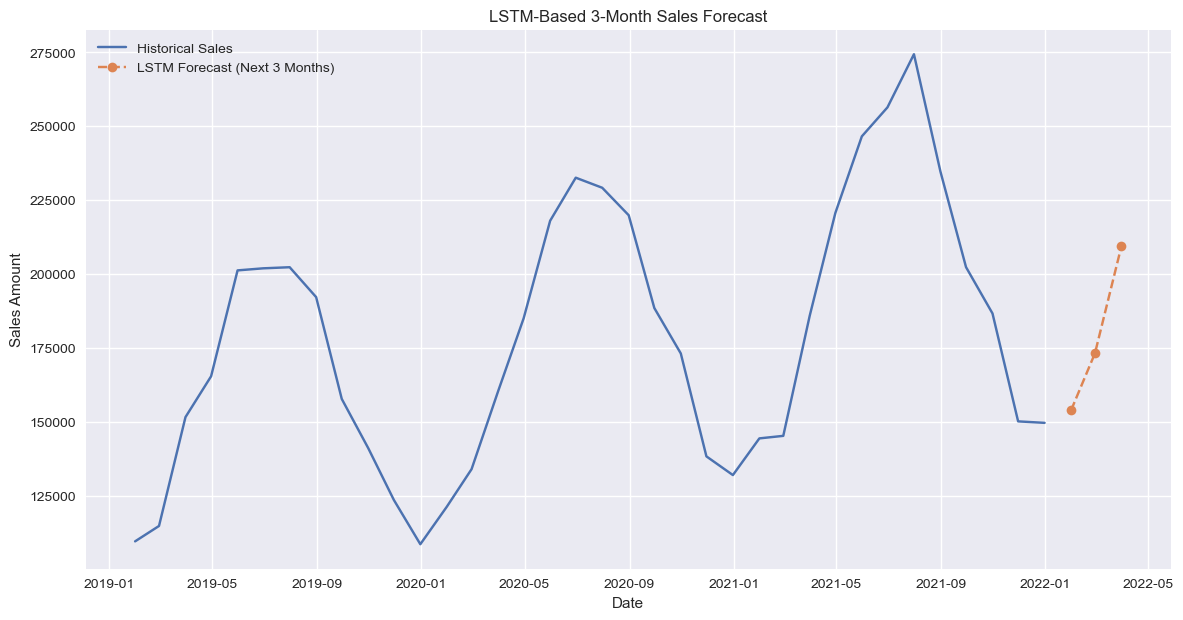

In [62]:
# Plot historical vs LSTM forecasted sales
plt.figure(figsize=(14, 7))
plt.plot(
    lstm_series['date'],
    lstm_series['sales_amount'],
    label='Historical Sales'
)
plt.plot(
    lstm_forecast_df['date'],
    lstm_forecast_df['forecasted_sales'],
    label='LSTM Forecast (Next 3 Months)',
    linestyle='--',
    marker='o'
)
plt.xlabel("Date")
plt.ylabel("Sales Amount")
plt.title("LSTM-Based 3-Month Sales Forecast")
plt.legend()
plt.show()

## Inference: LSTM 3-Month Sales Forecast

- The LSTM model successfully generated sales forecasts for the next 3 months.
- Forecasted values align with recent historical trends.
- LSTM effectively captures sequential dependencies in time-series data.
- These forecasts can support:
  - Short-term inventory planning
  - Staffing decisions
  - Tactical business strategies


##  Final Conclusion

In this capstone project, an end-to-end **Sales Forecasting system** was successfully developed
using both **Machine Learning** and **Deep Learning** techniques.

Key outcomes of the project include:
- Comprehensive **EDA** revealed clear trends, seasonality, and restaurant-wise performance patterns.
- Business insights identified **popular items**, **top revenue-generating restaurants**, and **premium menu offerings**.
- Among Machine Learning models, **XGBoost Regression** achieved the best performance with the lowest RMSE and was selected for one-year sales forecasting.
- A **Deep Learning LSTM model** was implemented to capture sequential dependencies and evaluated using **MAPE**, providing accurate short-term forecasts.
- The final **3-month LSTM forecast** offers actionable insights for short-term planning, while the **1-year ML forecast** supports long-term strategic decisions.

Overall, this project demonstrates the practical application of AI and Machine Learning
to solve real-world business problems and provides a scalable framework
for data-driven decision-making in the retail and restaurant domain.
